# 01 Installed scikit-learn library.

# 02 Importing Libraries 

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
%matplotlib inline

In [6]:
pd.set_option('display.max_columns',None)

In [7]:
path = r'C:\Users\shaiv\Downloads\Victoria Airbnb Analysis\02 Data'

In [8]:
vic_listings = pd.read_csv(os.path.join(path, 'Prepared Data', 'victoria_cleaned_2.csv'))

# 03 Cleaning Data

In [10]:
# List of columns
vic_listings.columns

Index(['id', 'scrape_id', 'host_id', 'host_since', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_identity_verified',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'calendar_last_scraped', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'listings_count', 'listings_count_home', 'listings_count_p_rooms',
       'listings_count_s_rooms', 'reviews_per_month'],
      dtype='object')

In [11]:
# Display first 5 rows
vic_listings.head()

,id,scrape_id,host_id,host_since,host_response_rate,host_acceptance_rate,host_is_superhost,host_identity_verified,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,listings_count,listings_count_home,listings_count_p_rooms,listings_count_s_rooms,reviews_per_month
0,83515,20241229042348,455118,2011-03-21,100.0,97.000000,1,1,Salt Spring Island,Salt Spring Island,48.86222,-123.49996,Entire guest suite,Entire home/apt,2,1.0,1.0,0.0,"[""Free parking on premises"", ""Dishes and silve...",175.0,2,730,1,8,23,44,289,2024-12-29,148,13,0,4.88,4.89,4.87,4.92,4.84,4.94,4.75,1,2.0,2,0,0,0.89
1,168460,20241229042348,802981,2011-07-10,100.0,87.101145,0,0,James Bay,Victoria,48.41620,-123.36790,Entire townhouse,Entire home/apt,3,2.5,2.0,2.0,"[""Free parking on premises"", ""Dishes and silve...",200.0,60,180,1,23,53,83,173,2024-12-29,64,0,0,4.91,4.90,4.98,4.89,4.92,5.00,4.90,0,1.0,1,0,0,0.42
2,185732,20241229042348,880366,2011-07-27,10.0,0.000000,0,1,Highlands,Highlands,48.50589,-123.46357,Private room in home,Private room,5,1.0,2.0,2.0,"[""Free parking on premises"", ""Hair dryer"", ""Sm...",199.0,1,365,1,30,60,90,365,2024-12-29,52,0,0,4.72,4.67,4.65,4.82,4.88,4.61,4.61,0,3.0,0,3,0,0.32
3,193366,20241229042348,937766,2011-08-07,75.0,100.000000,0,1,Rockland,Victoria,48.42574,-123.33760,Entire guest suite,Entire home/apt,6,2.0,2.0,3.0,"[""Free parking on premises"", ""Dishes and silve...",135.0,30,365,1,14,17,44,259,2024-12-29,157,1,0,4.75,4.83,4.78,4.92,4.89,4.88,4.76,1,1.0,1,0,0,1.00
4,201427,20241229042348,880366,2011-07-27,10.0,0.000000,0,1,Highlands,Highlands,48.50459,-123.46259,Private room in home,Private room,3,1.0,1.0,1.0,"[""Free parking on premises"", ""Indoor fireplace...",69.0,1,730,1,30,60,90,363,2024-12-29,51,0,0,4.63,4.80,4.78,4.96,5.00,4.58,4.68,0,3.0,0,3,0,0.34


In [12]:
# Check shape
vic_listings.shape

(3277, 44)

In [19]:
# Check for missing values
vic_listings.isnull().sum()

id                              0
scrape_id                       0
host_id                         0
host_since                      0
host_response_rate              0
host_acceptance_rate            0
host_is_superhost               0
host_identity_verified          0
neighbourhood_cleansed          0
neighbourhood_group_cleansed    0
latitude                        0
longitude                       0
property_type                   0
room_type                       0
accommodates                    0
bathrooms                       0
bedrooms                        0
beds                            0
amenities                       0
price                           0
minimum_nights                  0
maximum_nights                  0
has_availability                0
availability_30                 0
availability_60                 0
availability_90                 0
availability_365                0
calendar_last_scraped           0
number_of_reviews               0
number_of_revi

##### There are no missing values.

In [24]:
# Check for duplicate data
dups = vic_listings.duplicated()
dups.shape

(3277,)

##### There are no duplicate values.

### Check for extreme values

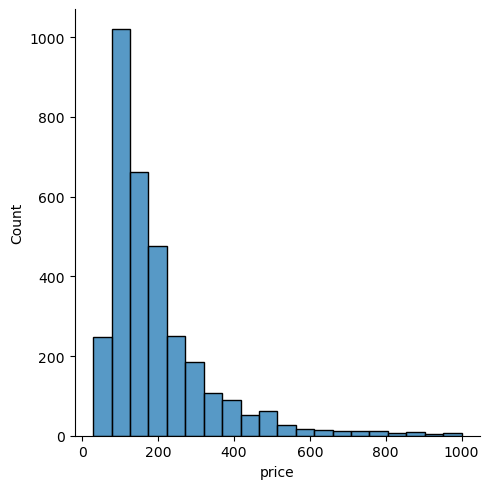

In [28]:
# Column price should not have value higher than 1000
sns.displot(vic_listings['price'], bins = 20)
plt.show()

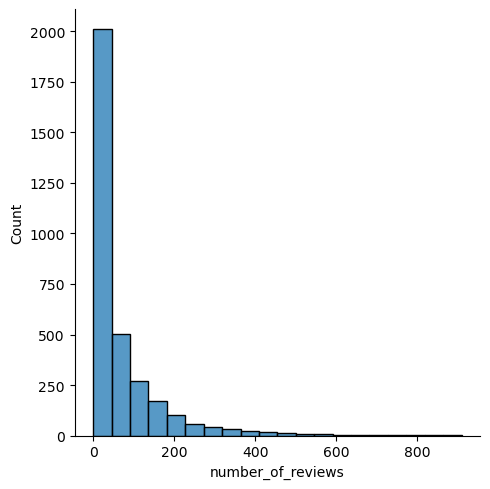

In [30]:
# Column no of reviews no more than 1000
sns.displot(vic_listings['number_of_reviews'], bins = 20)
plt.show()

##### There are no extreme values in the columns price and bedrooms.

# 04 Exploring data visually

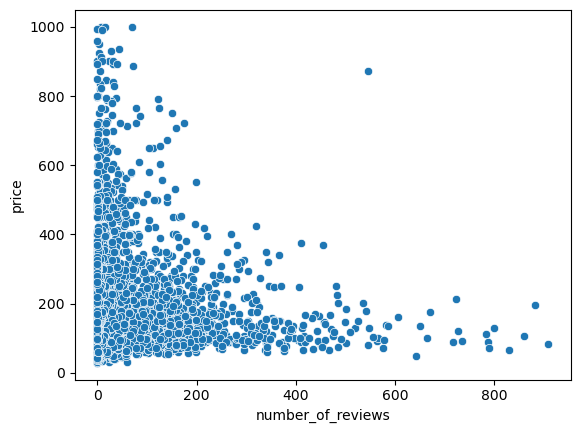

In [34]:
# Looking at variables number_of_reviews and price
sns.scatterplot(x = 'number_of_reviews', y = 'price', data = vic_listings)
plt.show()

##### This could indicate that budget-friendly listings are more popular and frequently booked, leading to more reviews, while higher-priced properties might be niche or booked less frequently.

# 05 If an Airbnb listing has a lower price, then it is more likely to receive a higher number of reviews, indicating greater booking frequency and broader guest appeal. Conversely, if a listing has a higher price, then it is likely to have fewer reviews, suggesting lower booking frequency or a more niche target market.

# 06 Reshape variables into NumPy arrays

In [39]:
X = vic_listings['number_of_reviews'].values.reshape(-1,1)
y = vic_listings['price'].values.reshape(-1,1)

# 07 Split data into two sets: a training set and a test set

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

# 08 Running Linear Regression of the Data

In [45]:
# Creating regression object
regression = LinearRegression()

In [47]:
# Fitting regression object into the training set
regression.fit(X_train, y_train)

LinearRegression()

In [49]:
# Predict values of y using X
y_predicted = regression.predict(X_test)

# 09 Creating the plot

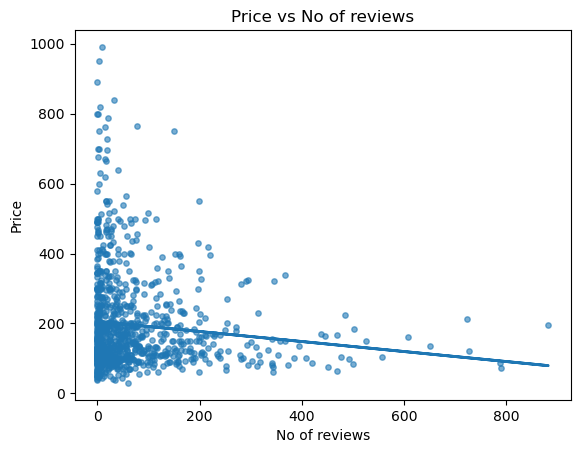

In [52]:
plot_test = plt
plot_test.scatter(X_test, y_test, s = 15, alpha = 0.6)
plot_test.plot(X_test, y_predicted, linewidth = 2)
plot_test.title('Price vs No of reviews')
plot_test.xlabel('No of reviews')
plot_test.ylabel('Price')
plot_test.show()

# 10 

##### After plotting the regression line on the scatterplot of price vs. number of reviews, it appears that the line does not fit the data very well. The data points are highly dispersed, particularly in the lower range of both variables, with a significant concentration of points in the bottom-left corner of the plot. This clustering suggests a right-skewed distribution, where most listings are low-priced and have few to moderate reviews. The regression line indicates a weak negative relationship between price and number of reviews as the price increases, the number of reviews tends to decrease slightly. However, due to the wide scatter of data and presence of outliers, the line does not capture much of the variance in the dataset. 

# 11 Model performance statistics — MSE and R2 score

In [56]:
mse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)

In [58]:
# Evaluating the performance model
print('Slope:', regression.coef_)
print('Mean squared error:', mse)
print('R2 score:', r2)

Slope: [[-0.14313318]]
Mean squared error: 19104.91381641946
R2 score: 0.009223266139901098


# 12 Predicting y values with the actual y values in a dataframe

In [65]:
data = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_predicted.flatten()})
data.head(30)

,Actual,Predicted
0,120.0,204.939554
1,275.0,204.223888
2,150.0,180.463780
3,99.0,196.065297
4,107.0,204.080755
5,160.0,205.512087
6,317.0,204.939554
7,113.0,204.223888
8,48.0,205.655220
9,128.0,205.655220


# 13 

##### The linear regression model predicting Airbnb listing prices based on the number of reviews performed poorly, as indicated by a very low R2 score of 0.0092 and a high mean squared error of approximately 19,104.91. This suggests that the number of reviews explains less than 1% of the variation in price, confirming a very weak linear relationship. Although the negative slope aligns with the initial observation that lower priced listings tend to receive more reviews, the model lacks predictive power. One possible reason for this poor performance is the skewed distribution of data, with most listings clustered at lower price and review counts. Additionally, the presence of outliers and exclusion of important variables such as location, room type, and amenities likely contributed to the model's limited accuracy. These factors highlight the impact of data bias and the need for a more comprehensive analysis to better understand the determinants of listing prices.